# Data Visualization

* 1. Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

* Load Data

In [ ]:
def data():
    df = pd.read_csv('data/transformed_clean_sales_data.csv')
    return df

df = data()

In [5]:
df

,OrderDate,SalesID,SalesName,InvoiceNo,CustomerName,OrderValue,DiscountValue,SalesValue,SalesReturn,CreditedAmount,Commission,Year,Month,Day,CustomerID,NetSales,DueAmount
0,2025-01-01,EMWS001,Al Amin,INV000001,Nan,0.0,0.0,0.0,0.0,0.0,0.0,2025,January,2025-01-01,CUST00115,0.0,0.0
1,2025-03-01,EMWS001,Al Amin,INV000002,Rahaman Corporation,0.0,0.0,0.0,0.0,25000.0,0.0,2025,March,2025-03-01,CUST00131,0.0,-25000.0
2,2025-05-01,EMWS001,Al Amin,INV000003,Popular Alumium,0.0,0.0,0.0,0.0,44300.0,0.0,2025,May,2025-05-01,CUST00127,0.0,-44300.0
3,2025-06-01,EMWS001,Al Amin,INV000004,Silvia Crockerise,0.0,0.0,0.0,0.0,21000.0,0.0,2025,June,2025-06-01,CUST00165,0.0,-21000.0
4,2025-08-01,EMWS001,Al Amin,INV000005,Supper Pavillion,16175.5,0.0,16175.5,0.0,0.0,0.0,2025,August,2025-08-01,CUST00170,16175.5,16175.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
877,2025-07-08,EMWS008,Yousuf Mazumder Anik,INV000615,Friends Crockeries,0.0,0.0,0.0,0.0,18600.0,0.0,2025,July,2025-07-08,CUST00060,0.0,-18600.0
878,2025-07-08,EMWS008,Yousuf Mazumder Anik,ORD0000162,Grameen Crockeries,0.0,0.0,0.0,0.0,5450.0,0.0,2025,July,2025-07-08,CUST00063,0.0,-5450.0
879,2025-07-08,EMWS008,Yousuf Mazumder Anik,INV000616,Mohammadia Trading,0.0,0.0,0.0,0.0,0.0,0.0,2025,July,2025-07-08,CUST00105,0.0,0.0
880,2025-07-08,EMWS008,Yousuf Mazumder Anik,INV000617,Raisa Store,0.0,0.0,0.0,0.0,0.0,0.0,2025,July,2025-07-08,CUST00134,0.0,0.0


##### 2. TOP SALES EXECUTIVES

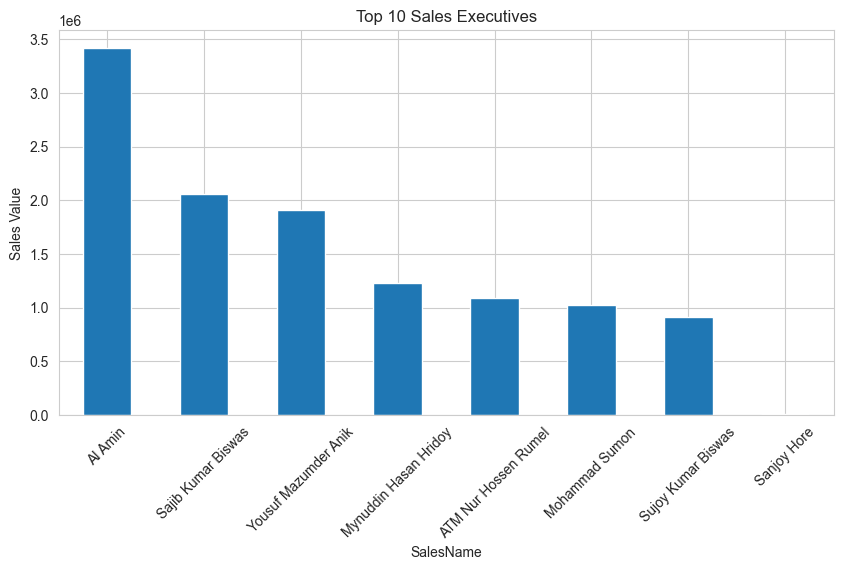

In [6]:
exec_sales = df.groupby('SalesName')['SalesValue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
exec_sales.plot(kind='bar')
plt.title("Top 10 Sales Executives")
plt.ylabel("Sales Value")
plt.xticks(rotation=45)
plt.show()

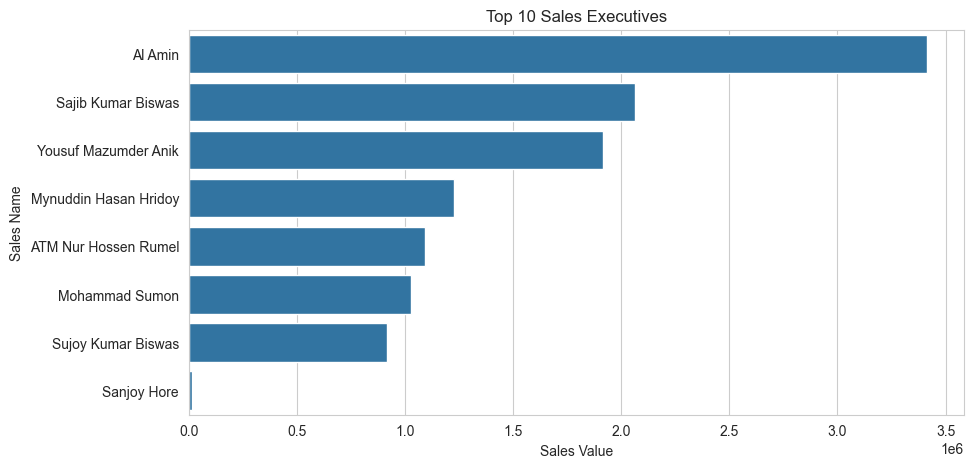

In [7]:
plt.figure(figsize=(10,5))
sns.barplot(x=exec_sales.values, y=exec_sales.index)
plt.title("Top 10 Sales Executives")
plt.xlabel("Sales Value")
plt.ylabel("Sales Name")
plt.show()

#### 👤 3. TOP CUSTOMERS

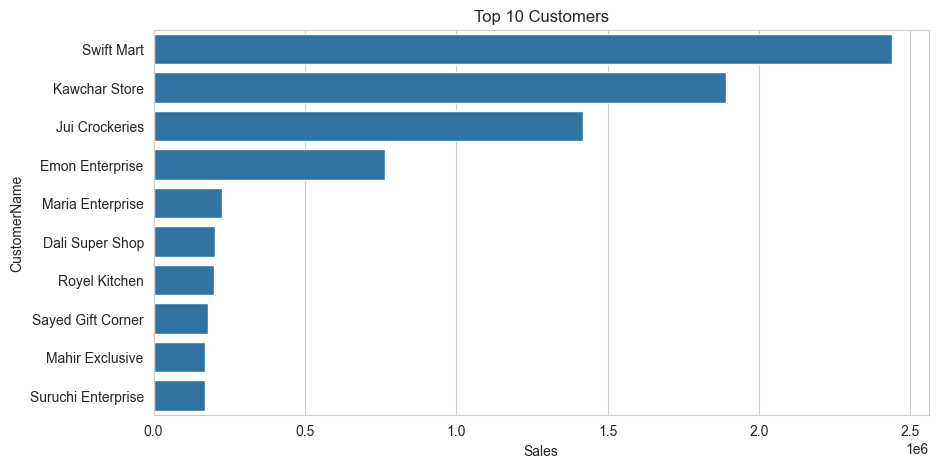

In [8]:
top_customers = df.groupby('CustomerName')['SalesValue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_customers.values, y=top_customers.index)
plt.title("Top 10 Customers")
plt.xlabel("Sales")
plt.show()

#### 📈 4. MONTHLY SALES TREND

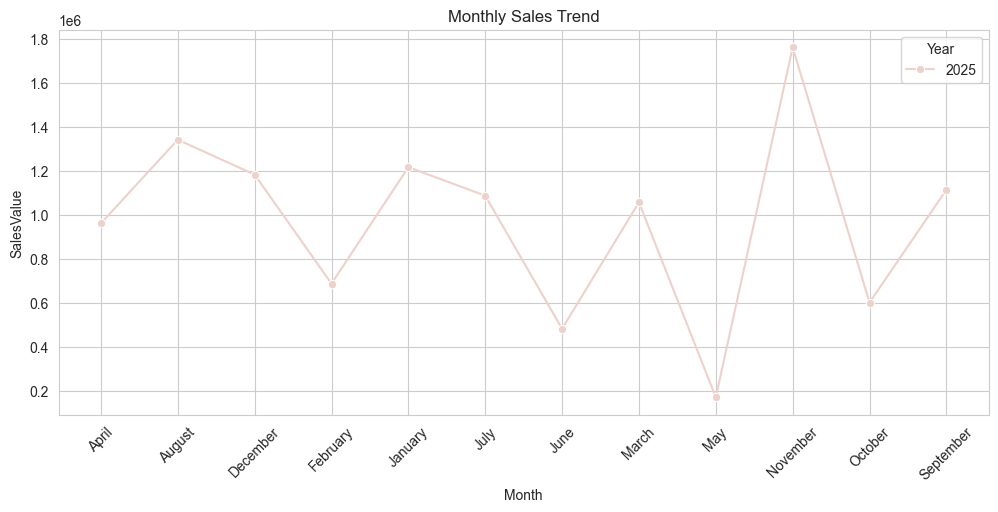

In [9]:
monthly = df.groupby(['Year','Month'])['SalesValue'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x='Month', y='SalesValue', hue='Year', marker='o')
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.show()

#### 💰 5. SALES vs COLLECTION

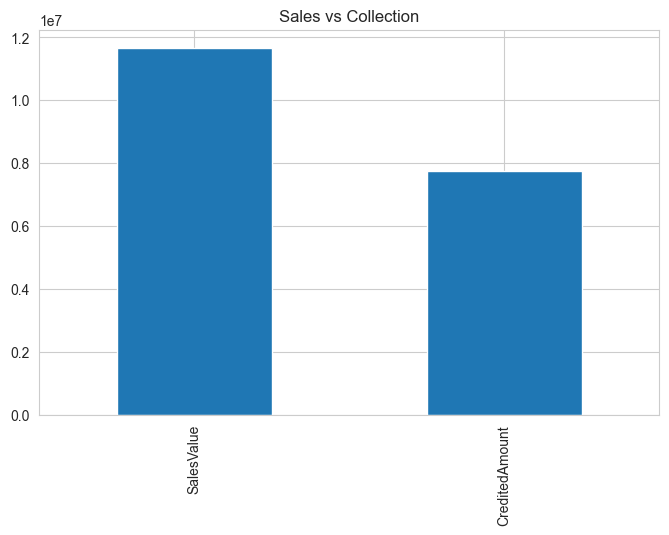

In [10]:
plt.figure(figsize=(8,5))

df[['SalesValue','CreditedAmount']].sum().plot(kind='bar')
plt.title("Sales vs Collection")
plt.show()

#### ⚠️ 6. DUE ANALYSIS

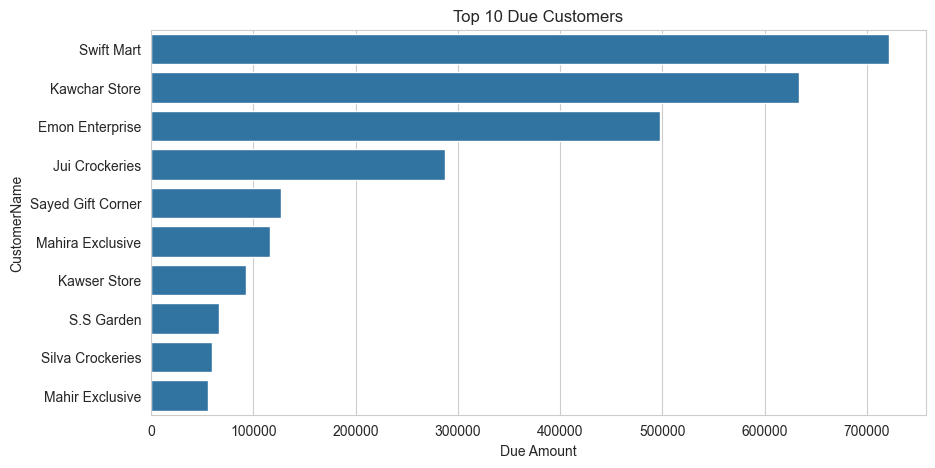

In [11]:
due = df.groupby('CustomerName')['DueAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=due.values, y=due.index)
plt.title("Top 10 Due Customers")
plt.xlabel("Due Amount")
plt.show()

#### 📊 7. DISTRIBUTION (SALES VALUE)

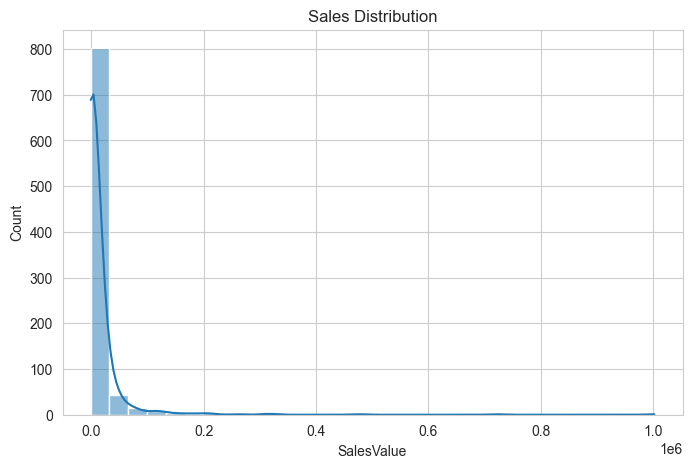

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalesValue'], bins=30, kde=True)
plt.title("Sales Distribution")
plt.show()

#### 📦 8. OUTLIERS (BOXPLOT)

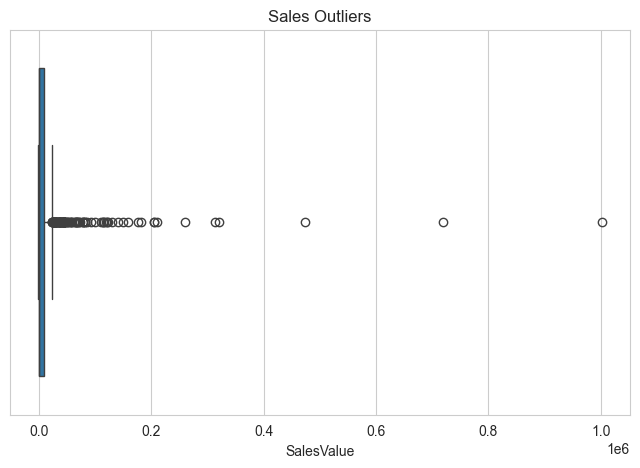

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['SalesValue'])
plt.title("Sales Outliers")
plt.show()

#### 9. CORRELATION HEATMAP

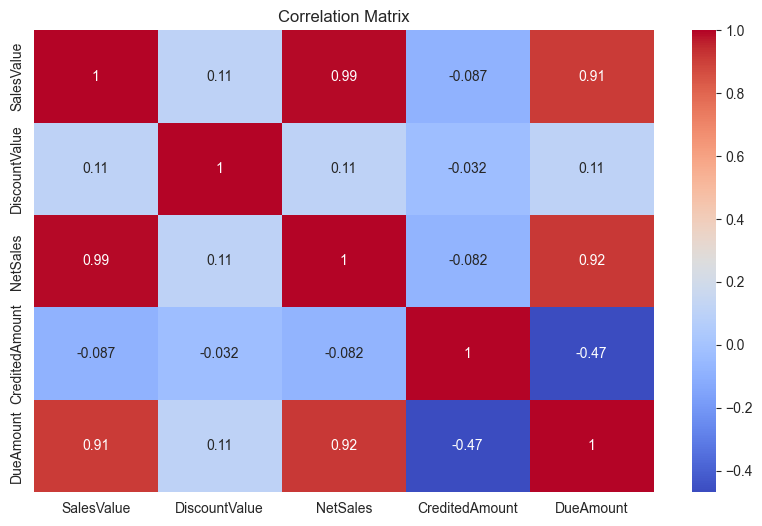

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['SalesValue','DiscountValue','NetSales','CreditedAmount','DueAmount']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#### 10. CUSTOMER BEHAVIOR (ADVANCED)
* Sales Frequency

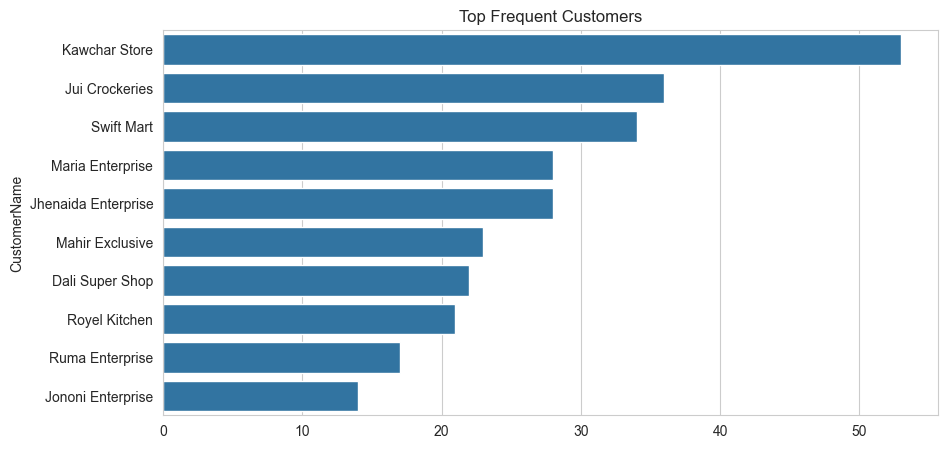

In [15]:
freq = df['CustomerName'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=freq.values, y=freq.index)
plt.title("Top Frequent Customers")
plt.show()